In [2]:
# Carga de datos y revisión de características
#
# En esta práctica cargamos el conjunto de datos de recomendación de cultivos
# y revisamos su estructura, tipos de datos, estadísticas y valores faltantes.
# La columna `label` representa el cultivo recomendado; las demás columnas
# describen condiciones del suelo y del ambiente.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# El kernel del notebook trabaja desde la carpeta `notebooks`.
data_path = Path("../data/processed/crop.parquet")


if not data_path.exists():
    raise FileNotFoundError(f"No se encontró el archivo: {data_path.resolve()}")

df = pd.read_parquet(data_path)

print(f"Archivo cargado: {data_path}")
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")



# Con esta revisión comprobamos el tamaño del conjunto, los tipos de datos,
# la escala de las variables y si hace falta tratar valores faltantes antes
# de entrenar un modelo.

Archivo cargado: ..\data\processed\crop.parquet
Filas: 2,200 | Columnas: 8


In [3]:
# 1. Estructura y tipos de datos.
# `shape` muestra el tamaño, `dtypes` los tipos y `head` las primeras filas.
print("\nShape:", df.shape)
print("\nTipos de datos:\n", df.dtypes)
print("\nPrimeras filas:\n", df.head())




Shape: (2200, 8)

Tipos de datos:
 N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label              str
dtype: object

Primeras filas:
     N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice


In [4]:
# 2. Estadísticas descriptivas y valores faltantes.
# `describe` resume las columnas numéricas y `isnull` cuenta valores ausentes.
print("\nEstadísticas descriptivas:\n", df.describe())
print("\nValores faltantes por columna:\n", df.isnull().sum())
print("\nNúmero de valores distintos por columna:\n", df.nunique())




Estadísticas descriptivas:
                  N            P            K  temperature     humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50.551818    53.362727    48.149091    25.616244    71.481779   
std      36.917334    32.985883    50.647931     5.063749    22.263812   
min       0.000000     5.000000     5.000000     8.825675    14.258040   
25%      21.000000    28.000000    20.000000    22.769375    60.261953   
50%      37.000000    51.000000    32.000000    25.598693    80.473146   
75%      84.250000    68.000000    49.000000    28.561654    89.948771   
max     140.000000   145.000000   205.000000    43.675493    99.981876   

                ph     rainfall  
count  2200.000000  2200.000000  
mean      6.469480   103.463655  
std       0.773938    54.958389  
min       3.504752    20.211267  
25%       5.971693    64.551686  
50%       6.425045    94.867624  
75%       6.923643   124.267508  
max       9.935091   298.560117 

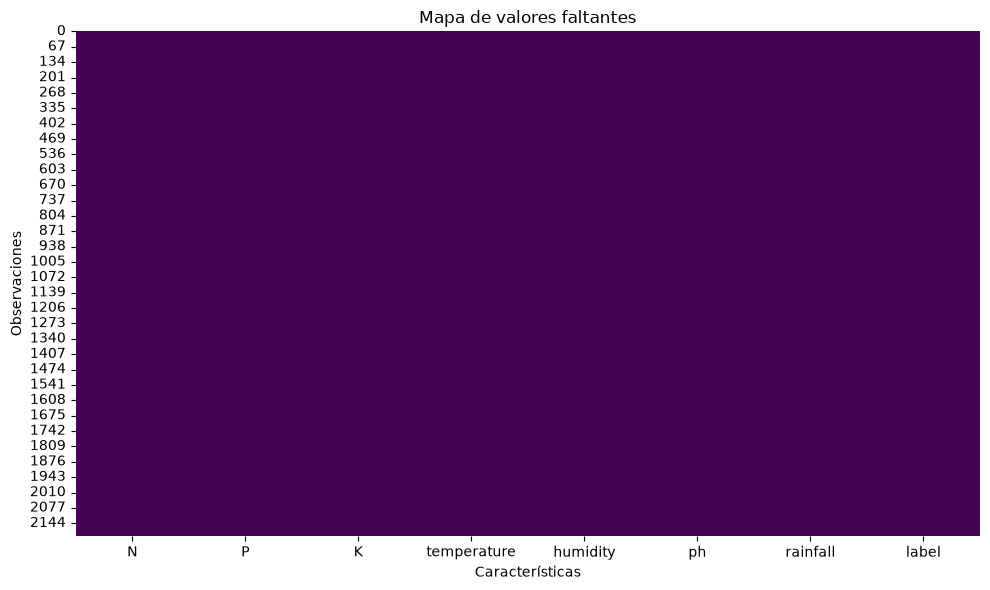

In [5]:
# 3. Visualización de valores faltantes.
# Cada celda representa una observación y una columna del conjunto de datos.
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Mapa de valores faltantes")
plt.xlabel("Características")
plt.ylabel("Observaciones")
plt.tight_layout()
plt.show()

## Análisis univariado

El análisis univariado estudia una variable a la vez. En este caso observaremos la distribución, la dispersión y la frecuencia de las características numéricas, además del balance de la variable objetivo `label`.

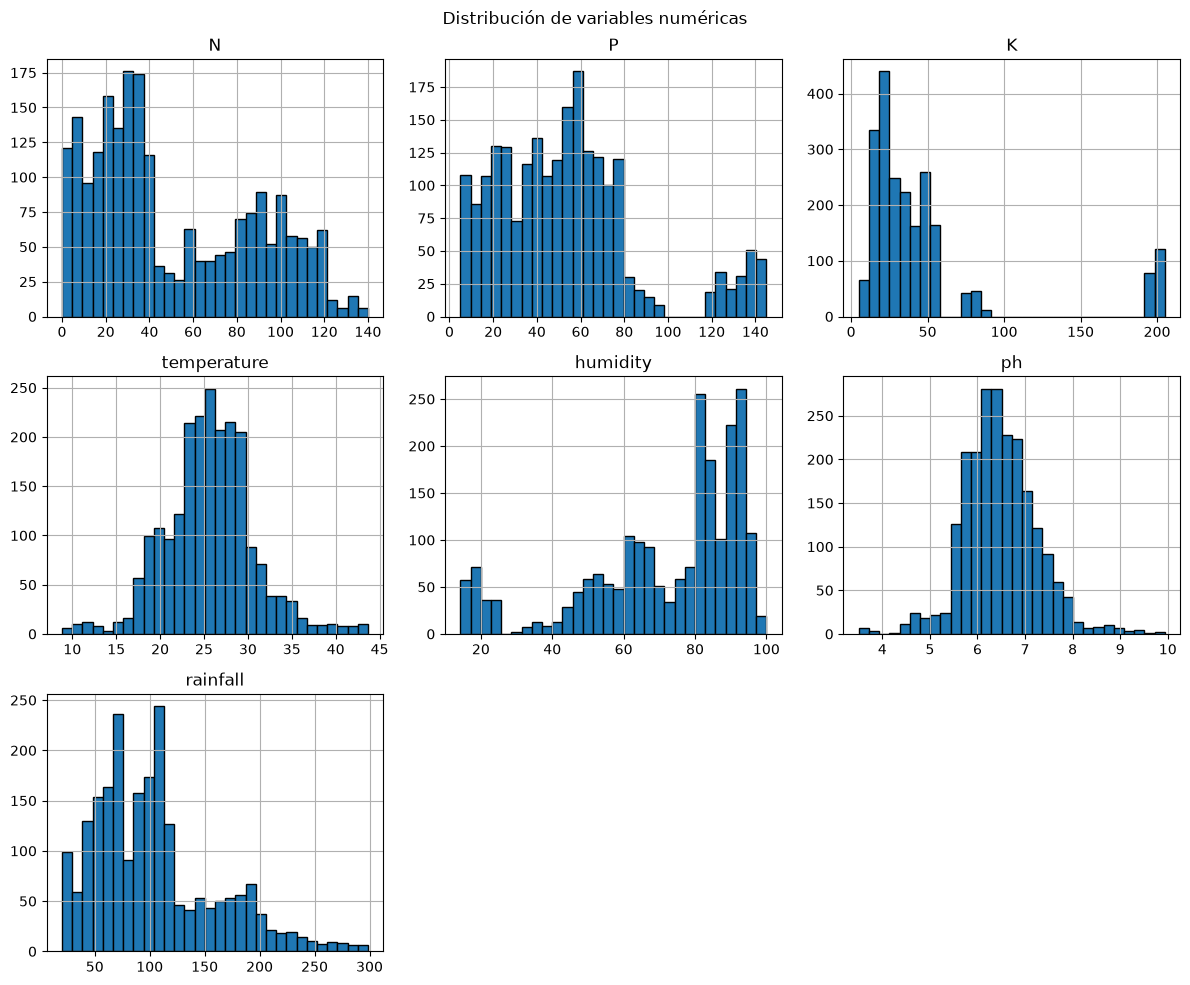

In [6]:
# Histogramas de todas las variables numéricas
# Permiten observar la forma, el centro y la dispersión de cada variable.
df.hist(figsize=(12, 10), bins=30, edgecolor="black")
plt.suptitle("Distribución de variables numéricas")
plt.tight_layout()
plt.show()

## Resultados de los histogramas

Los histogramas muestran los siguientes patrones:

- **N:** presenta una distribución irregular y con varios grupos de valores. Hay observaciones concentradas aproximadamente entre 0 y 40, y otro grupo entre 80 y 120.
- **P:** tiene una distribución amplia y multimodal. Se observan concentraciones cerca de 20-80 y también valores altos alrededor de 120-145.
- **K:** concentra la mayoría de los datos entre 5 y 55, con grupos separados de valores cercanos a 70-90 y 190-205.
- **temperature:** se concentra principalmente entre 20 y 30 grados, con una forma aproximadamente acampanada y pocos valores en los extremos.
- **humidity:** presenta varios grupos, con una concentración importante entre 80 y 100 y otro grupo de valores más bajos.
- **ph:** se concentra alrededor de 6 y 7, aunque aparecen observaciones en los extremos, aproximadamente entre 3.5 y 10.
- **rainfall:** muestra una distribución asimétrica hacia la derecha. La mayoría de los valores está por debajo de 125, pero también hay observaciones que alcanzan cerca de 300.

En conjunto, algunas variables tienen distribuciones multimodales o sesgadas. Esto puede indicar que los cultivos se desarrollan bajo condiciones ambientales diferentes.

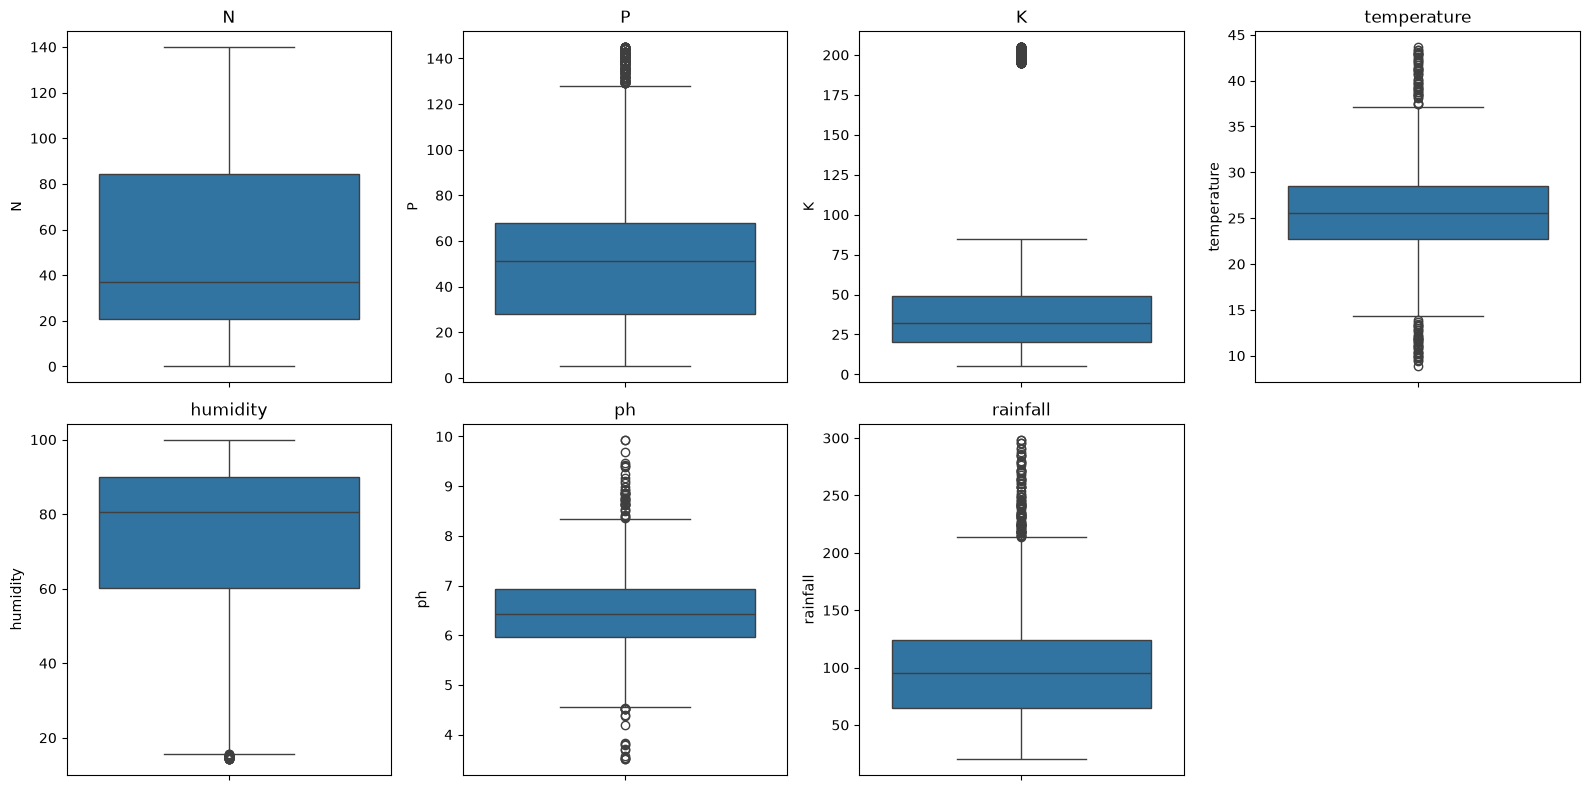

In [7]:
# Boxplots de las variables numéricas
# Permiten comparar medianas, dispersión y posibles valores atípicos.
numeric_columns = df.select_dtypes(include="number").columns

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for index, column in enumerate(numeric_columns):
    axis = axes[index // 4, index % 4]
    sns.boxplot(y=df[column], ax=axis)
    axis.set_title(column)

# Ocultamos los ejes sobrantes si hay menos de ocho variables numéricas.
for index in range(len(numeric_columns), axes.size):
    axes.flat[index].set_visible(False)

plt.tight_layout()
plt.show()

## Resultados de los boxplots

Los boxplots permiten complementar los histogramas:

- **N:** tiene una dispersión amplia, aproximadamente entre 0 y 140, sin una cantidad destacada de puntos aislados.
- **P:** presenta valores atípicos altos por encima de aproximadamente 125.
- **K:** muestra valores atípicos muy altos, cercanos a 200, separados del grupo principal.
- **temperature:** concentra la mitad de los datos aproximadamente entre 23 y 29 grados, con valores atípicos bajos y altos.
- **humidity:** la mayor parte de los datos está entre aproximadamente 60 y 90; se observan algunos valores bajos como posibles atípicos.
- **ph:** está centrado cerca de 6.4 y presenta valores atípicos tanto por debajo de 4.5 como por encima de 8.3.
- **rainfall:** tiene una dispersión elevada y numerosos valores atípicos altos, superiores aproximadamente a 210.

Los puntos atípicos no deben eliminarse automáticamente. Primero hay que comprobar si representan mediciones válidas o condiciones reales de determinados cultivos.

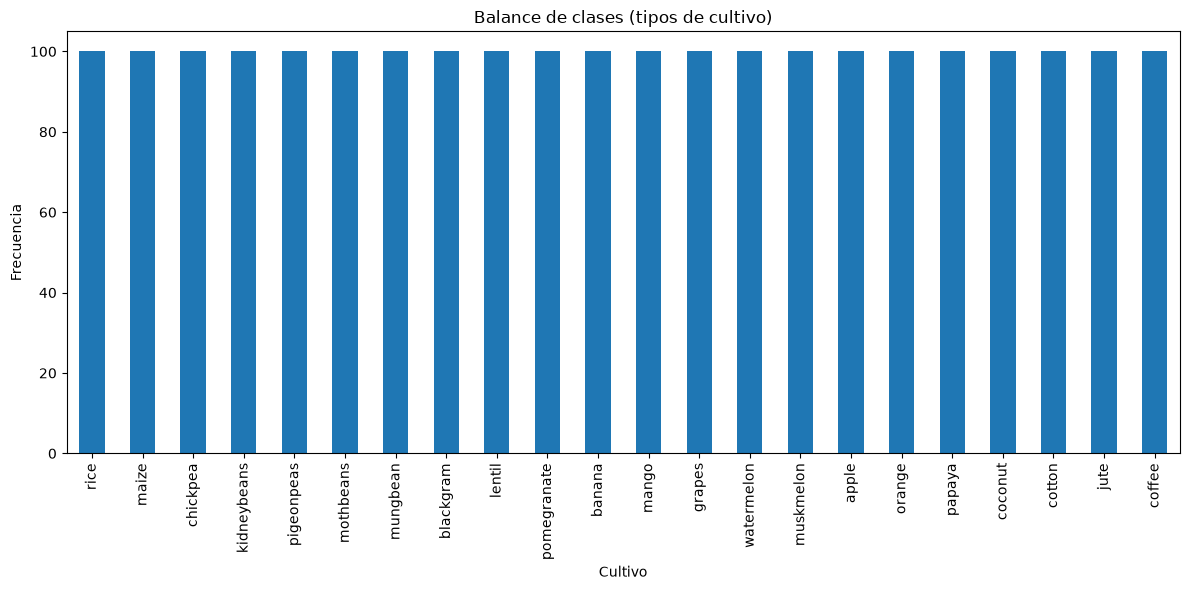

In [8]:
# Balance de clases
# La frecuencia de cada cultivo permite evaluar si la variable objetivo está equilibrada.
plt.figure(figsize=(12, 6))
df["label"].value_counts().plot(kind="bar")
plt.title("Balance de clases (tipos de cultivo)")
plt.xlabel("Cultivo")
plt.ylabel("Frecuencia")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Resultados del balance de clases

El gráfico muestra que los 22 cultivos tienen una frecuencia de aproximadamente 100 observaciones cada uno. Por tanto, la variable objetivo está equilibrada y no se observa una clase dominante.

Este equilibrio es favorable para entrenar un modelo de clasificación, porque las métricas no estarán dominadas por una sola categoría. Aun así, conviene volver a revisar la distribución después de separar los datos en entrenamiento y prueba.

## Análisis bivariado y multivariado

El análisis bivariado estudia la relación entre dos variables. El análisis multivariado observa simultáneamente varias características para identificar patrones, grupos y posibles relaciones útiles para la recomendación de cultivos.

En esta sección se utilizarán todas las variables numéricas (`N`, `P`, `K`, `temperature`, `humidity`, `ph` y `rainfall`) y `label` como variable categórica.

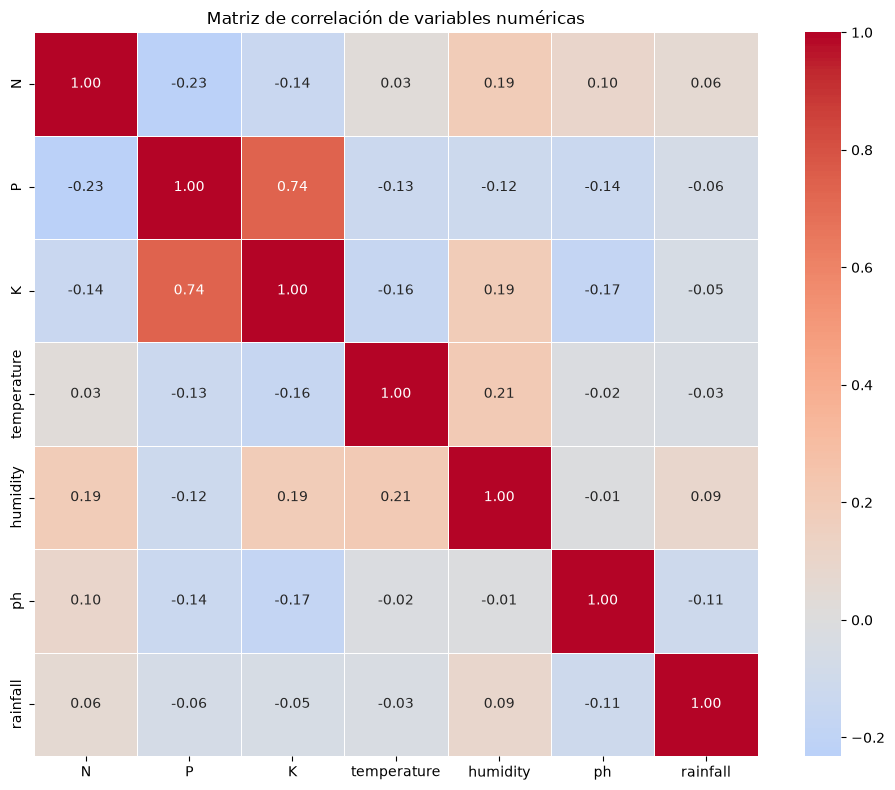

Correlaciones más fuertes entre variables diferentes:
P - K: 0.74
P - N: -0.23
temperature - humidity: 0.21
K - humidity: 0.19
humidity - N: 0.19


In [9]:
# Matriz de correlación de todas las variables numéricas
# La correlación de Pearson varía entre -1 y 1:
# valores cercanos a 1 o -1 indican una relación lineal fuerte.
numeric_data = df.select_dtypes(include="number")
correlation_matrix = numeric_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    square=True,
    linewidths=0.5,
)
plt.title("Matriz de correlación de variables numéricas")
plt.tight_layout()
plt.show()

print("Correlaciones más fuertes entre variables diferentes:")
correlations = correlation_matrix.where(
    ~pd.DataFrame(
        __import__("numpy").eye(len(correlation_matrix)),
        index=correlation_matrix.index,
        columns=correlation_matrix.columns,
    ).astype(bool)
).stack().abs().sort_values(ascending=False)

reported_pairs = set()
for pair, absolute_value in correlations.items():
    ordered_pair = tuple(sorted(pair))
    if ordered_pair not in reported_pairs:
        reported_pairs.add(ordered_pair)
        print(f"{pair[0]} - {pair[1]}: {correlation_matrix.loc[pair[0], pair[1]]:.2f}")
    if len(reported_pairs) == 5:
        break

## Interpretación de la matriz de correlación

La matriz muestra que:

- **P y K** tienen una correlación positiva fuerte (`r = 0.74`). En este conjunto, los registros con mayor fósforo suelen presentar también mayor potasio. Esta relación debe vigilarse al entrenar modelos lineales porque ambas variables aportan información parcialmente compartida.
- **P y N** presentan una relación negativa débil (`r = -0.23`). La asociación existe, pero no es suficientemente fuerte para afirmar que una variable determine a la otra.
- **temperature y humidity** tienen una relación positiva débil (`r = 0.21`). No se observa una dependencia lineal importante entre ambas condiciones ambientales.
- Las relaciones de `ph` y `rainfall` con el resto de variables son débiles, con valores absolutos cercanos a cero.

En general, no hay evidencia de multicolinealidad generalizada. La única relación que requiere atención es `P-K`; aun así, la correlación no implica causalidad y debe interpretarse junto con el cultivo recomendado.

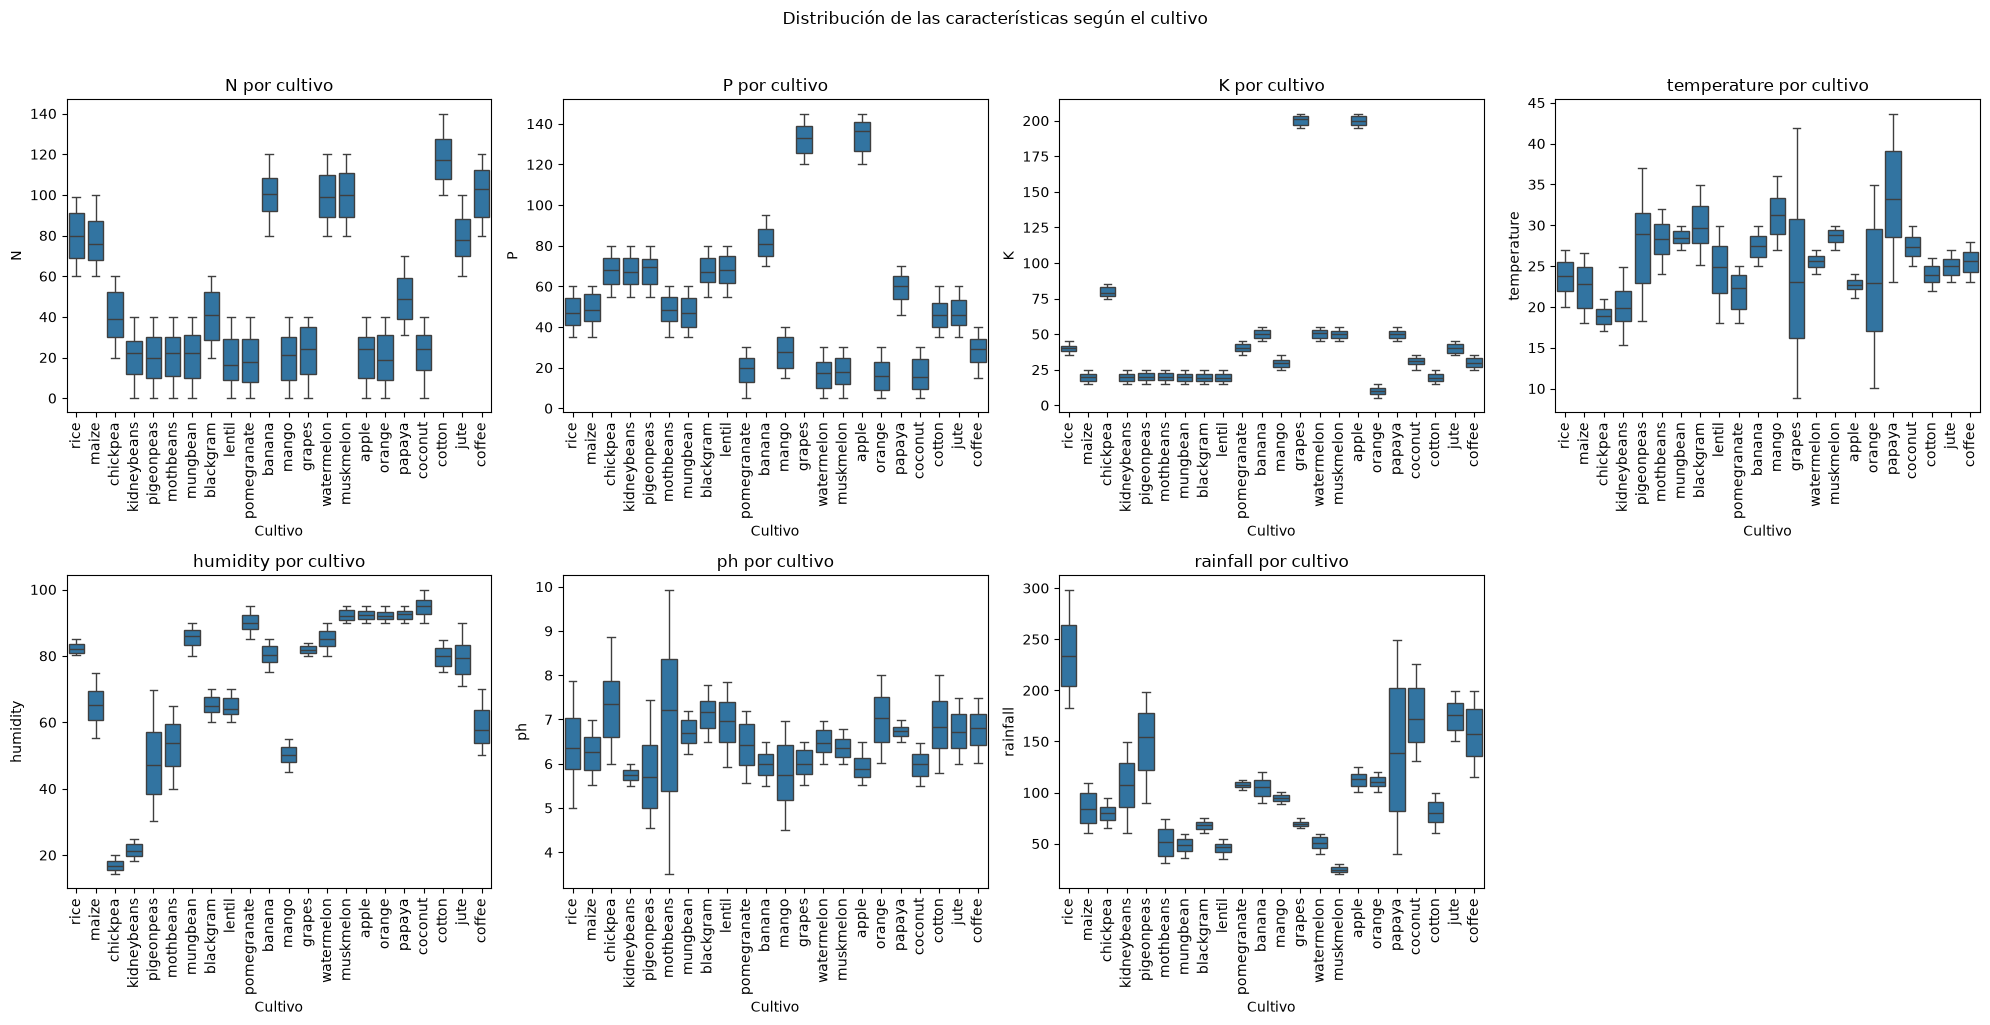

In [10]:
# Comparación de todas las características numéricas por cultivo
# Estos boxplots permiten estudiar cada variable numérica frente a label.
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for index, column in enumerate(numeric_columns):
    axis = axes.flat[index]
    sns.boxplot(data=df, x="label", y=column, ax=axis)
    axis.set_title(f"{column} por cultivo")
    axis.set_xlabel("Cultivo")
    axis.set_ylabel(column)
    axis.tick_params(axis="x", rotation=90)

for index in range(len(numeric_columns), axes.size):
    axes.flat[index].set_visible(False)

plt.suptitle("Distribución de las características según el cultivo", y=1.02)
plt.tight_layout()
plt.show()

## Interpretación de las características por cultivo

Los boxplots muestran que las variables tienen capacidad de diferenciar cultivos:

- **N, P y K:** presentan medianas muy distintas según el cultivo. `K` separa con claridad los cultivos con valores cercanos a 200, mientras que `P` distingue grupos con valores altos cercanos a 130-140. Estas variables parecen aportar información importante sobre la composición del suelo.
- **temperature:** las medianas cambian entre cultivos, aunque algunos grupos se solapan. La temperatura por sí sola no separa completamente todas las clases.
- **humidity:** muestra una separación marcada. Algunos cultivos se concentran en humedades bajas, mientras que otros presentan medianas superiores a 80 o 90.
- **ph:** las medianas suelen estar entre 5.5 y 7.5, pero la variabilidad cambia según el cultivo. Algunas clases tienen rangos más amplios y podrían ser menos fáciles de distinguir con esta variable aislada.
- **rainfall:** presenta diferencias importantes entre cultivos. Hay clases asociadas con lluvias moderadas y otras con valores altos, además de grupos con gran dispersión.

La conclusión bivariada es que ninguna variable debe analizarse de forma aislada para tomar una decisión. La combinación de nutrientes y condiciones ambientales ofrece una representación más informativa del cultivo recomendado.

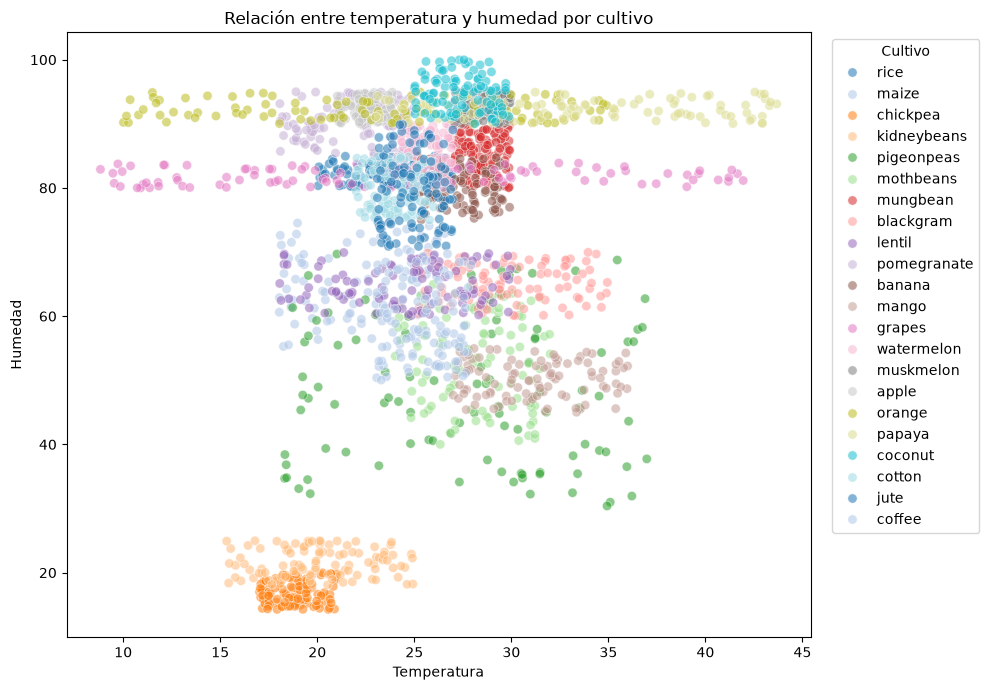

In [11]:
# Relación bivariada entre temperatura y humedad
# El color representa el cultivo para observar posibles agrupaciones.
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df,
    x="temperature",
    y="humidity",
    hue="label",
    palette="tab20",
    alpha=0.55,
    s=45,
)
plt.title("Relación entre temperatura y humedad por cultivo")
plt.xlabel("Temperatura")
plt.ylabel("Humedad")
plt.legend(title="Cultivo", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Interpretación de temperatura y humedad

El scatter plot confirma una correlación lineal débil, pero revela agrupaciones asociadas al cultivo:

- Los cultivos no se distribuyen uniformemente en el plano temperatura-humedad.
- Algunas clases ocupan regiones muy definidas, como los cultivos con humedad baja y los que requieren humedad cercana a 80-95.
- Existe solapamiento entre varios cultivos en la zona central, por lo que temperatura y humedad no bastan por sí solas para separar todas las clases.
- La variable `label` aporta una estructura categórica que no aparece completamente en la correlación numérica.

Este resultado muestra por qué una correlación baja no significa que las variables sean inútiles: pueden formar grupos cuando se analizan junto con la clase objetivo.

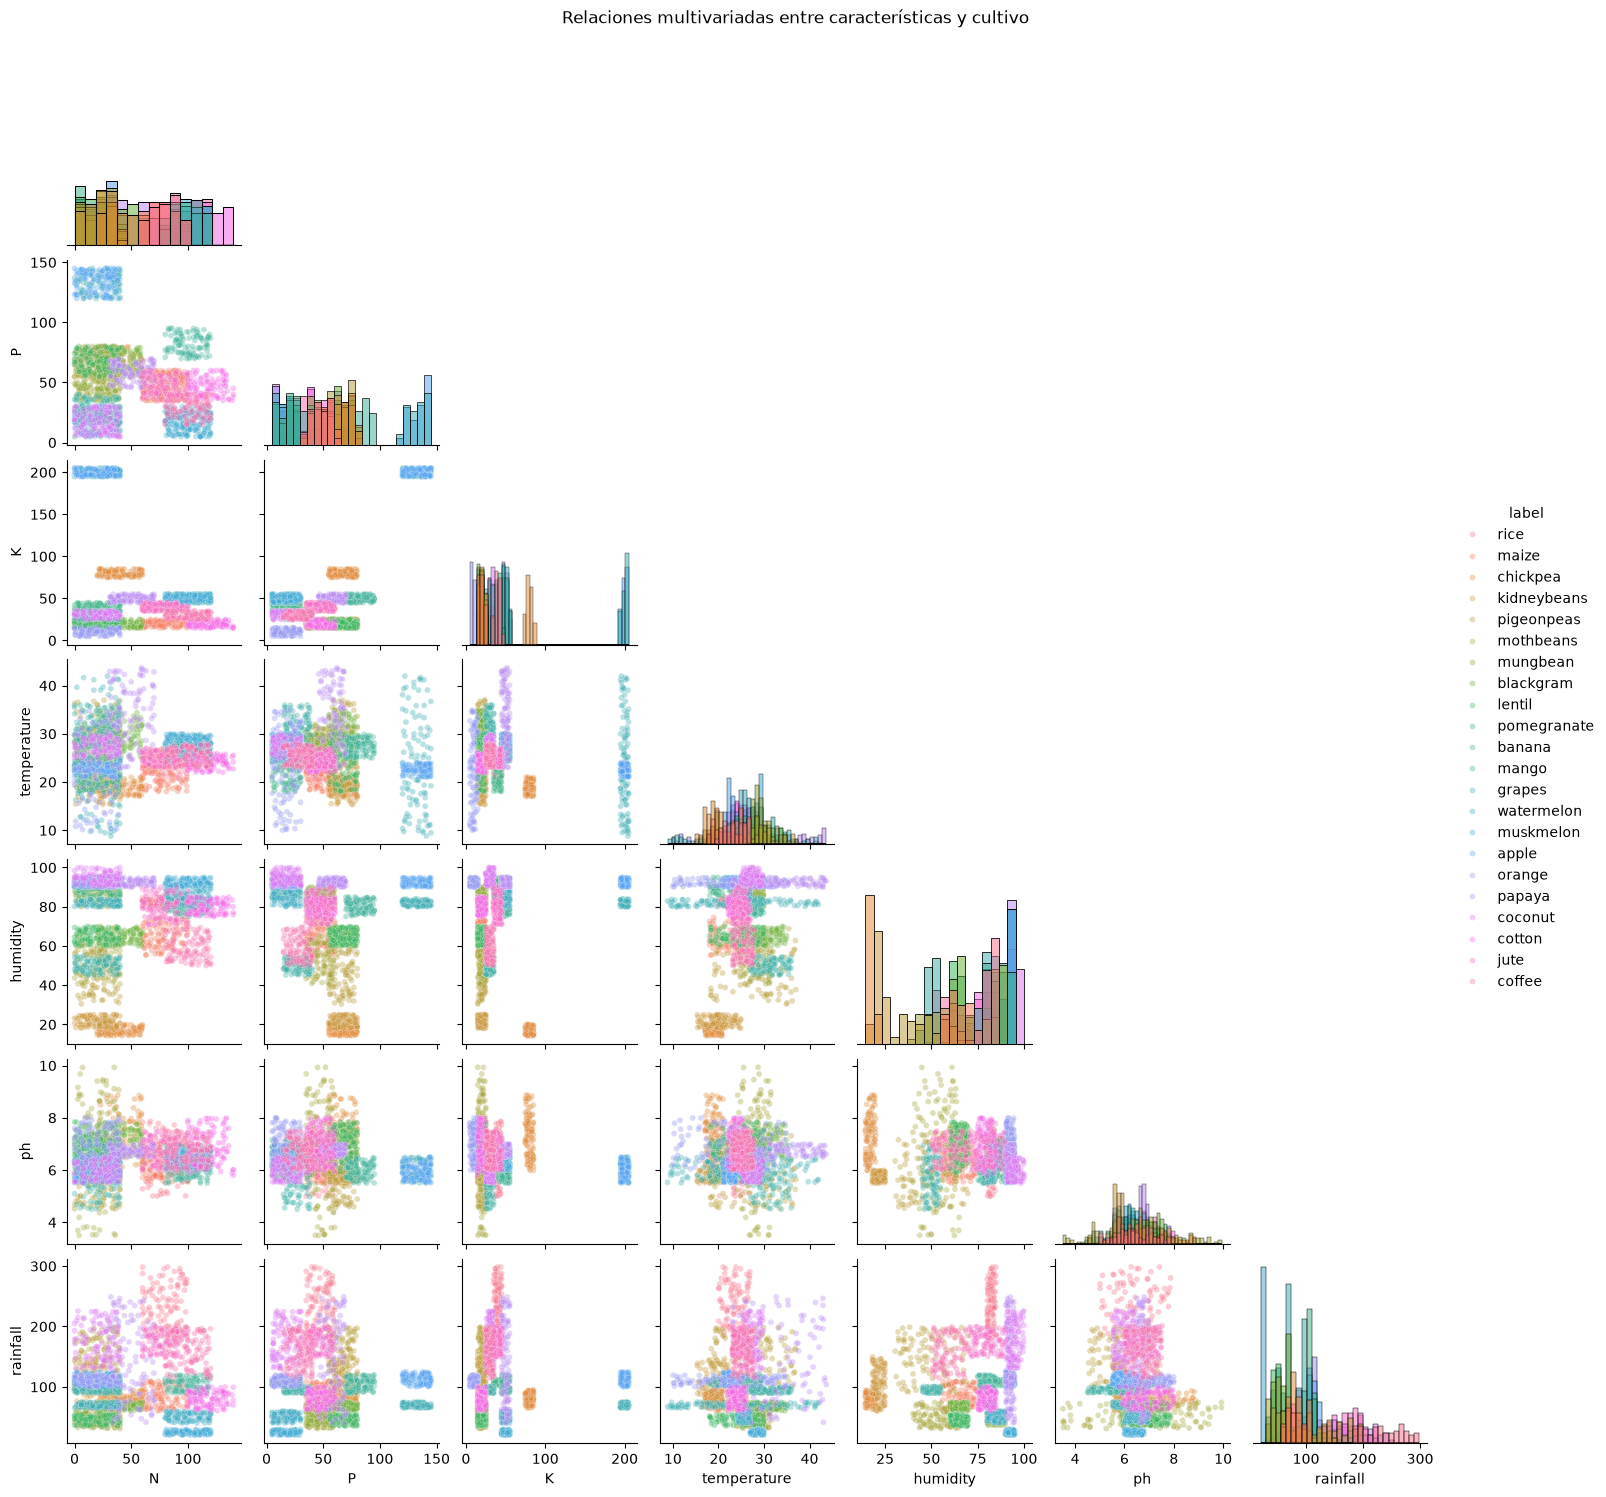

In [12]:
# Pairplot multivariado de todas las variables numéricas
# Permite observar relaciones por pares y la separación de los cultivos.
sns.pairplot(
    df,
    vars=list(numeric_columns),
    hue="label",
    corner=True,
    diag_kind="hist",
    plot_kws={"alpha": 0.35, "s": 18},
    height=2.1,
)
plt.suptitle("Relaciones multivariadas entre características y cultivo", y=1.02)
plt.show()

## Interpretación del análisis multivariado

El pairplot permite analizar simultáneamente todas las variables numéricas y observar patrones que no aparecen en una sola gráfica:

- Las combinaciones de **N, P y K** forman grupos diferenciados para varios cultivos. La relación `P-K` es visible y coincide con la correlación positiva encontrada en la matriz.
- **K** presenta agrupaciones muy separadas en algunos cultivos, especialmente alrededor de valores bajos, medios y cercanos a 200. Es una característica potencialmente muy discriminante.
- **humidity** también organiza los datos en bandas y grupos. Al combinarla con `temperature`, se observan regiones ambientales asociadas con diferentes cultivos.
- **rainfall** ayuda a distinguir perfiles de cultivo, aunque presenta dispersión y solapamiento en algunas clases.
- **ph** tiene una relación lineal débil con las demás variables y mayor solapamiento entre clases; probablemente sea más útil en combinación con nutrientes y condiciones ambientales.
- Ningún par de variables separa perfectamente las 22 clases. Por esta razón, un modelo de clasificación deberá aprovechar simultáneamente todas las características.

### Conclusión

El análisis bivariado y multivariado indica que el problema tiene estructura clasificable: existen grupos de cultivos con perfiles diferenciados de nutrientes, humedad, temperatura y lluvia. La correlación alta entre `P` y `K` debe considerarse al evaluar modelos lineales, pero no justifica eliminar una variable sin comparar el rendimiento. El siguiente paso recomendado es dividir los datos en entrenamiento y prueba, escalar las variables cuando el algoritmo lo requiera y entrenar un modelo de clasificación.

In [13]:
# Exportar el resumen EDA como artefacto del pipeline.
import json
from pathlib import Path


processed_dir = Path("../data/processed")
data_path = processed_dir / "crop.parquet"
df = pd.read_parquet(data_path)
numeric_data = df.select_dtypes(include="number")
target_column = "label" if "label" in df.columns else None

report = {
    "source_file": data_path.name,
    "row_count": df.shape[0],
    "column_count": df.shape[1],
    "columns": df.columns.tolist(),
    "data_types": df.dtypes.astype(str).to_dict(),
    "missing_values": df.isna().sum().to_dict(),
    "descriptive_statistics": numeric_data.describe().to_dict(),
    "correlation_matrix": numeric_data.corr().to_dict(),
    "target_column": target_column,
    "class_distribution": (
        df[target_column].value_counts().to_dict() if target_column else {}
    ),
}


def json_safe(value):
    if isinstance(value, dict):
        return {str(key): json_safe(item) for key, item in value.items()}
    if isinstance(value, list):
        return [json_safe(item) for item in value]
    if pd.isna(value):
        return None
    if hasattr(value, "item"):
        return json_safe(value.item())
    return value


output_path = processed_dir / "eda_sumary.json"
with output_path.open("w", encoding="utf-8") as output_file:
    json.dump(json_safe(report), output_file, ensure_ascii=False, indent=2, allow_nan=False)

with output_path.open(encoding="utf-8") as output_file:
    json.load(output_file)

print(f"Informe EDA guardado y validado: {output_path.resolve()}")

Informe EDA guardado y validado: C:\Users\marco\ml-demo1-profesor\data\processed\eda_sumary.json
